In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets


(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"Date antrenare: {X_train.shape}, Etichete antrenare: {y_train.shape}")
print(f"Date test: {X_test.shape}, Etichete test: {y_test.shape}")

Date antrenare: (60000, 28, 28, 1), Etichete antrenare: (60000,)
Date test: (10000, 28, 28, 1), Etichete test: (10000,)


In [ ]:
from tensorflow.keras import layers, models

def create_baseline_model():
    model = models.Sequential([
        
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'), 
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = create_baseline_model()
baseline_model.summary()


print("\n Antrenare Model Baseline")
history_baseline = baseline_model.fit(
    X_train, y_train, 
    epochs=3, 
    batch_size=64, 
    validation_split=0.2
)

c:\Users\User1\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Antrenare Model Baseline ---
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9356 - loss: 0.2167 - val_accuracy: 0.9818 - val_loss: 0.0661
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9813 - loss: 0.0606 - val_accuracy: 0.9835 - val_loss: 0.0601
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9884 - val_loss: 0.0471


In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras import layers, models, optimizers
import numpy as np

subset_size = 10000
X_train_sub = X_train[:subset_size]
y_train_sub = y_train[:subset_size]

def train_and_evaluate_model(learning_rate, num_filters, dropout_rate, activation_fn, batch_size):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_accuracies = []
    
    for train_idx, val_idx in kf.split(X_train_sub):
        X_tr, X_val = X_train_sub[train_idx], X_train_sub[val_idx]
        y_tr, y_val = y_train_sub[train_idx], y_train_sub[val_idx]
        
        
        model = models.Sequential([
           
            layers.Conv2D(num_filters, (3, 3), activation=activation_fn, input_shape=(28, 28, 1)),
            layers.MaxPooling2D((2, 2)),
            
            
            layers.Conv2D(64, (3, 3), activation=activation_fn),
            layers.MaxPooling2D((2, 2)),
            
            layers.Flatten(),
            layers.Dropout(dropout_rate), 
            layers.Dense(64, activation=activation_fn),
            layers.Dense(10, activation='softmax')
        ])
        
        model.compile(
            optimizer=optimizers.Adam(learning_rate=learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        model.fit(X_tr, y_tr, epochs=2, batch_size=batch_size, verbose=0)
        
        
        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accuracies.append(acc)
        
    return np.mean(fold_accuracies)

In [4]:
import itertools
import time

grid_space = {
    'learning_rate': [0.001, 0.01],
    'num_filters': [16, 32],
    'batch_size': [64, 128]
}

fixed_dropout = 0.2
fixed_activation = 'relu'

best_grid_score = 0
best_grid_params = None

print("Pornim Grid Search")
start_time = time.time()

keys, values = zip(*grid_space.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

for i, params in enumerate(experiments):
    print(f"Rularea {i+1}/{len(experiments)}: {params}")
    score = train_and_evaluate_model(
        learning_rate=params['learning_rate'],
        num_filters=params['num_filters'],
        dropout_rate=fixed_dropout,
        activation_fn=fixed_activation,
        batch_size=params['batch_size']
    )
    if score > best_grid_score:
        best_grid_score = score
        best_grid_params = params

grid_duration = time.time() - start_time
print(f" Grid Search finalizat in {grid_duration:.2f} secunde!")
print(f"Cel mai bun scor Grid Search: {best_grid_score:.4f} cu parametrii: {best_grid_params}")

Pornim Grid Search
Rularea 1/8: {'learning_rate': 0.001, 'num_filters': 16, 'batch_size': 64}
Rularea 2/8: {'learning_rate': 0.001, 'num_filters': 16, 'batch_size': 128}
Rularea 3/8: {'learning_rate': 0.001, 'num_filters': 32, 'batch_size': 64}
Rularea 4/8: {'learning_rate': 0.001, 'num_filters': 32, 'batch_size': 128}
Rularea 5/8: {'learning_rate': 0.01, 'num_filters': 16, 'batch_size': 64}
Rularea 6/8: {'learning_rate': 0.01, 'num_filters': 16, 'batch_size': 128}
Rularea 7/8: {'learning_rate': 0.01, 'num_filters': 32, 'batch_size': 64}
Rularea 8/8: {'learning_rate': 0.01, 'num_filters': 32, 'batch_size': 128}
 Grid Search finalizat in 103.08 secunde!
Cel mai bun scor Grid Search: 0.9671 cu parametrii: {'learning_rate': 0.01, 'num_filters': 16, 'batch_size': 128}


In [5]:
import random

print("\n Pornim Randomized Search")
start_time = time.time()

best_random_score = 0
best_random_params = None
n_iterations = 5

for i in range(n_iterations):
    # incercam valori aleatoare dintr-un interval mai mare
    params = {
        'learning_rate': random.choice([0.0005, 0.001, 0.005, 0.01]),
        'num_filters': random.choice([16, 32, 64]),
        'dropout_rate': random.choice([0.1, 0.2, 0.3]),
        'activation_fn': random.choice(['relu', 'tanh']),
        'batch_size': random.choice([32, 64, 128])
    }
    
    print(f"Rularea {i+1}/{n_iterations}: {params}")
    score = train_and_evaluate_model(
        learning_rate=params['learning_rate'],
        num_filters=params['num_filters'],
        dropout_rate=params['dropout_rate'],
        activation_fn=params['activation_fn'],
        batch_size=params['batch_size']
    )
    
    if score > best_random_score:
        best_random_score = score
        best_random_params = params

random_duration = time.time() - start_time
print(f" Randomized Search finalizat in {random_duration:.2f} secunde")
print(f"Cel mai bun scor Random Search: {best_random_score:.4f} cu parametrii: {best_random_params}")


 Pornim Randomized Search
Rularea 1/5: {'learning_rate': 0.005, 'num_filters': 64, 'dropout_rate': 0.2, 'activation_fn': 'relu', 'batch_size': 64}
Rularea 2/5: {'learning_rate': 0.005, 'num_filters': 16, 'dropout_rate': 0.1, 'activation_fn': 'relu', 'batch_size': 64}
Rularea 3/5: {'learning_rate': 0.005, 'num_filters': 32, 'dropout_rate': 0.1, 'activation_fn': 'tanh', 'batch_size': 64}
Rularea 4/5: {'learning_rate': 0.01, 'num_filters': 32, 'dropout_rate': 0.1, 'activation_fn': 'tanh', 'batch_size': 128}
Rularea 5/5: {'learning_rate': 0.005, 'num_filters': 32, 'dropout_rate': 0.2, 'activation_fn': 'relu', 'batch_size': 64}
 Randomized Search finalizat in 78.45 secunde
Cel mai bun scor Random Search: 0.9662 cu parametrii: {'learning_rate': 0.005, 'num_filters': 64, 'dropout_rate': 0.2, 'activation_fn': 'relu', 'batch_size': 64}


In [6]:
import optuna

# Oprim printurile optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    num_filters = trial.suggest_categorical('num_filters', [16, 32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    activation_fn = trial.suggest_categorical('activation_fn', ['relu', 'tanh'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    
    score = train_and_evaluate_model(
        learning_rate=learning_rate,
        num_filters=num_filters,
        dropout_rate=dropout_rate,
        activation_fn=activation_fn,
        batch_size=batch_size
    )
    return score

print("\n Pornim Bayesian Optimization (Optuna)")
start_time = time.time()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=13) 

bayesian_duration = time.time() - start_time
print(f" Bayesian Optimization finalizata in {bayesian_duration:.2f} secunde!")
print(f"Cel mai bun scor Bayesian: {study.best_value:.4f}")
print(f"Cei mai buni parametri: {study.best_params}")


 Pornim Bayesian Optimization (Optuna)


c:\Users\User1\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Bayesian Optimization finalizata in 220.65 secunde!
Cel mai bun scor Bayesian: 0.9695
Cei mai buni parametri: {'learning_rate': 0.004153391599381884, 'num_filters': 64, 'dropout_rate': 0.3965672335388539, 'activation_fn': 'relu', 'batch_size': 32}


 Antrenare Model Final
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9559 - loss: 0.1397 - val_accuracy: 0.9876 - val_loss: 0.0380
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9804 - loss: 0.0631 - val_accuracy: 0.9874 - val_loss: 0.0365
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9842 - loss: 0.0519 - val_accuracy: 0.9902 - val_loss: 0.0332
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9892 - val_loss: 0.0376
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.9896 - val_loss: 0.0345
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accuracy: 0.9910 - val_loss: 0.0267
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9892 - loss: 0.0344 - val_accuracy: 0.9899 - val_loss: 0.0391
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0

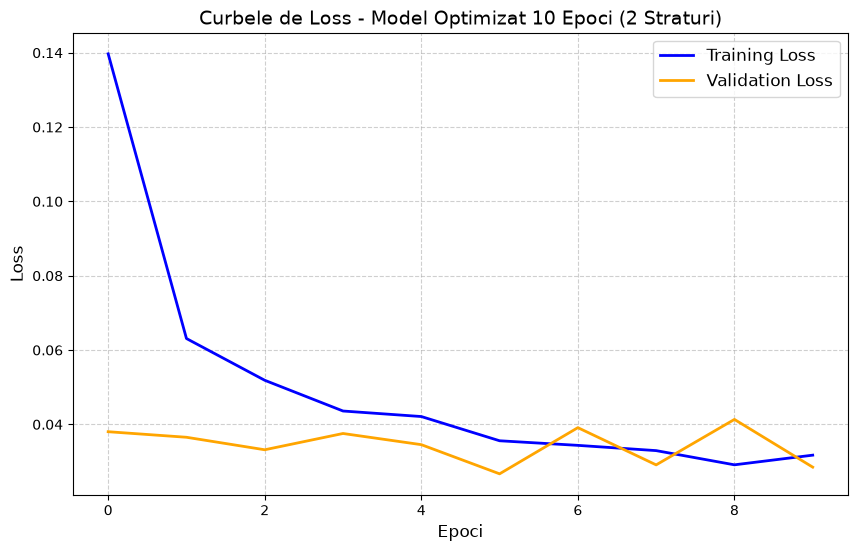

In [7]:
import matplotlib.pyplot as plt

final_model_10_epochs = models.Sequential([
    # Stratul 1 optimizat de Optuna
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.3965672335388539),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.004153391599381884)
final_model_10_epochs.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(" Antrenare Model Final")
history_10 = final_model_10_epochs.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64,
    validation_data=(X_test, y_test)
)

plt.figure(figsize=(10, 6))
plt.plot(history_10.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history_10.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Curbele de Loss - Model Optimizat 10 Epoci (2 Straturi)', fontsize=14)
plt.xlabel('Epoci', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 Antrenare Model Final cu early stopping automat
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9546 - loss: 0.1446 - val_accuracy: 0.9836 - val_loss: 0.0484
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9800 - loss: 0.0642 - val_accuracy: 0.9893 - val_loss: 0.0314
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9838 - loss: 0.0522 - val_accuracy: 0.9886 - val_loss: 0.0331
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9855 - loss: 0.0459 - val_accuracy: 0.9902 - val_loss: 0.0310
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.9902 - val_loss: 0.0332
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9888 - loss: 0.0360 - val_accuracy: 0.9891 - val_loss: 0.0361


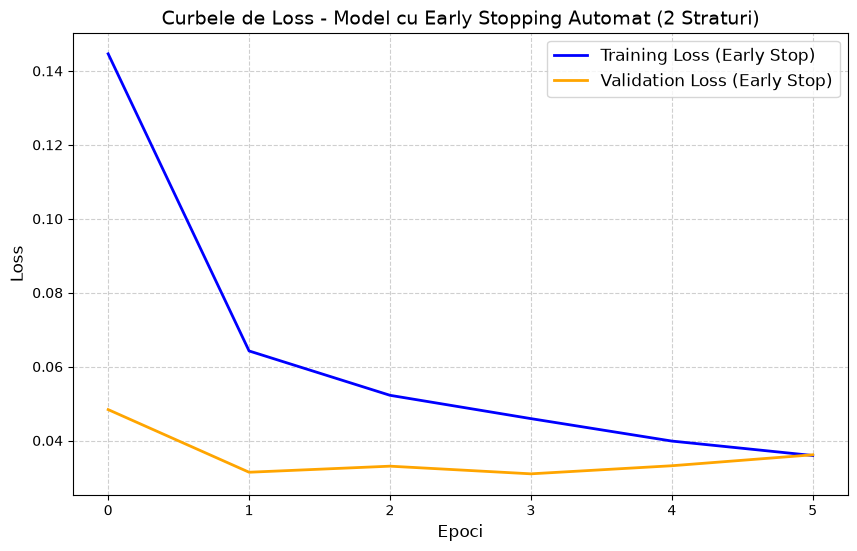

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


early_stop_model = models.Sequential([
   
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    # Dropout-ul exact din Optuna
    layers.Dropout(0.3965672335388539),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
optimizer = tf.keras.optimizers.Adam(learning_rate=.004153391599381884)
early_stop_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',     # monitorizam loss de validare 
    patience=2,             
    restore_best_weights=True 
)

print(" Antrenare Model Final cu early stopping automat")
history_early = early_stop_model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop] 
)

plt.figure(figsize=(10, 6))
plt.plot(history_early.history['loss'], label='Training Loss (Early Stop)', color='blue', linewidth=2)
plt.plot(history_early.history['val_loss'], label='Validation Loss (Early Stop)', color='orange', linewidth=2)
plt.title('Curbele de Loss - Model cu Early Stopping Automat (2 Straturi)', fontsize=14)
plt.xlabel('Epoci', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()